In [6]:
using Lattices
using LinearAlgebra
using Combinatorics
using SparseArrays
using CairoMakie
import Graphs
using LaTeXStrings
using Statistics
using Random
using Zygote
using Optimization, OptimizationOptimisers
using JSON
using OptimizationOptimJL
using JLD2
using ExponentialUtilities
using LsqFit
# using CUDA
using HDF5

if !isdefined(Main, :UtilityFunctions)
    include("utility_functions.jl")
end
include("ed_objects.jl")
include("ed_functions.jl")
include("ed_optimization.jl")
include("data_path.jl")


cmap1(L) = [Makie.ColorSchemes.roma[z] for z in range(0, 1, length=L)]
cmap2(L) = [Makie.ColorSchemes.managua[z] for z in range(0, 1, length=L)]


const FILE_LABEL_PAIRS = [
    (L"3\times 2\;(2,2)",   "N=(2, 2)_3x2", (2,2)),
    (L"3\times 2,\;(3,2)",  "N=(3, 2)_3x2", (3,2)),
    (L"3\times 2,\;(3,3)",  "N=(3, 3)_3x2", (3,3)),
    (L"3\times3,\;(3,2)",   "N=(3, 2)_3x3", (3,2)),
    (L"4\times2,\;(3,3)",   "N=(3, 3)_4x2", (3,3)),
    (L"3\times3,\;(3,3)",   "N=(3, 3)_3x3", (3,3)),
    (L"3\times3,\;(4,3)",   "N=(4, 3)_3x3", (4,3)),
    (L"3\times3,\;(4,4)",   "N=(4, 4)_3x3", (4,4)),
    (L"3\times3,\;(5,4)",   "N=(5, 4)_3x3", (5,4)),
    # (L"4\times3,\;(4,4)",   "N=(4, 4)_4x3", (4,4)),
    (L"4\times3,\;(5,4)",   "N=(5, 4)_4x3", (5,4)),
]

const FOLDER = get_data_root()

const THICKNESS_SCALE = 1.3
const BASE_FONTSIZE   = 16    # Makie default
const BASE_LINEWIDTH  = 2.5   # Makie default
const BASE_MARKERSIZE = 12    # Makie default

# set_theme!(
#     fontsize    = round(Int, BASE_FONTSIZE * THICKNESS_SCALE),
#     linewidth   = BASE_LINEWIDTH * THICKNESS_SCALE,
#     markersize  = BASE_MARKERSIZE * THICKNESS_SCALE,
#     Axis = (
#         xticksize    = 6 * THICKNESS_SCALE,
#         yticksize    = 6 * THICKNESS_SCALE,
#         xminorticksize = 4 * THICKNESS_SCALE,
#         yminorticksize = 4 * THICKNESS_SCALE,
#         spinewidth   = 1 * THICKNESS_SCALE,
#     ),
# )

function get_figsize(num_cols::Int, height_mm::Float64=55.0)
    px_per_mm = 96 / 25.4
    φ = (1+sqrt(5))/2
    if num_cols == 1
        width_mm = 89 # mm
    elseif num_cols == 2
        width_mm = 180 # mm
    else
        error("Can only have num_cols == 1 or 2 (given: $num_cols)")
    end
    width_px = width_mm * px_per_mm
    height_px = height_mm * px_per_mm
    println("Using width=$(width_mm/25.4)\" and height=$(height_mm/25.4)\"")
    return (width_px, height_px)
end
function create_fig(num_cols::Int, height_mm::Float64; kwargs...)
    fig = Figure(size=get_figsize(num_cols, height_mm), figure_padding=5)
    ax = Axis(fig[1, 1]; 
        aspect = (1+sqrt(5))/2,
        kwargs...
    )
    return fig, ax
end
const LEGEND_ARGS = Dict(:rowgap=>-8, :padding=>(3,3,0,0))
set_theme!(theme_latexfonts(), fontsize=10)

Using width=3.5039370078740157" and height=2.1653543307086616"


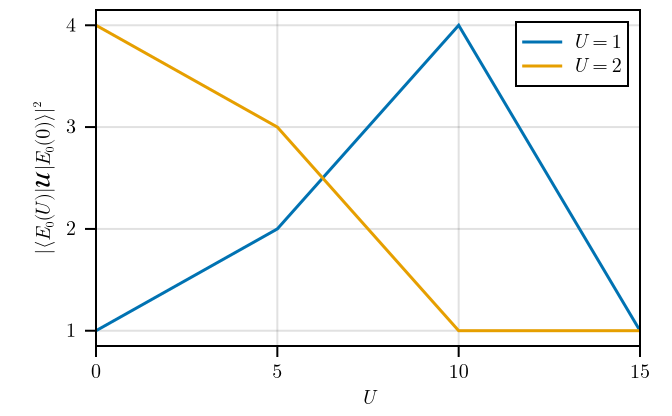

CairoMakie.Screen{IMAGE}


In [7]:
fig, ax = create_fig(1, 55.0;
    xlabel = L"U",
    ylabel = L"|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2",
    limits = ((0, 15),(nothing, nothing)),
)
lines!(ax, [0,5,10,15],[1,2,4,1], label=L"U=1")
lines!(ax, [0,5,10,15],[4,3,1,1], label=L"U=2")
# Legend(fig[1,2], ax)
axislegend(ax; LEGEND_ARGS...)
save("deleteme.pdf", fig)
display(fig)


In [38]:
for (_, folder,_) in FILE_LABEL_PAIRS
    U_values, target_vecs, indexer, precomputed_structures, N, spin_conserved, use_symmetry, sign_convention = load_ED_data(data_folder(folder); sign_convention=:spin_first, use_slater_reference=false)
    println(folder, " ", size(target_vecs,2))
end

N=(2, 2)_3x2 39
N=(3, 2)_3x2 50
N=(3, 3)_3x2 68
N=(3, 2)_3x3 336
N=(3, 3)_4x2 392
N=(3, 3)_3x3 792
N=(4, 3)_3x3 1176
N=(4, 4)_3x3 1764
N=(5, 4)_3x3 1764
N=(4, 4)_4x3 20439
N=(5, 4)_4x3 32670


In [10]:
dict = load("/home/jek354/research/data/new_data/data_h5_fixed/N=(3, 3)_3x3/trotter_N=9_num_exponentials=2_ref_slater_antihermitian_u_23.jld2")["dict"]["metrics"]

Dict{String, Vector{Any}} with 9 entries:
  "multistart_losses"   => [Vector{Float64}[]]
  "other"               => []
  "best_start_idx"      => [0]
  "stopping_reasons"    => [["Maximum iterations reached (maxiters)", "Maximum …
  "optimization_losses" => [[0.000321566, 0.000307711, 0.000300555, 0.000292237…
  "convergence_info"    => [Dict{String, Any}[Dict("optimizer"=>"LBFGS", "itera…
  "energy"              => [-6.5, -9.38573, -9.85437]
  "loss_std"            => [0.0]
  "loss"                => [0.850795, 2.73167e-6]

## Loss curves
In this figure, for the $(N_\uparrow, N_\downarrow)=(4,4)$ on the $3\times 3$ system, I plotted the loss curves of the optimization dependent on the $U$ value. This plot confirms that there is no reason to not reuse the reference state for the prior $U$ value. It's not stuck in a local minimum, it simply can't find a better state. The solid lines correspond to using the previous $U$ value's coefficients as initial coefficients, and the dotted line corresponds to randomly generating the coefficients each time.

Using width=7.086614173228347" and height=2.1653543307086616"


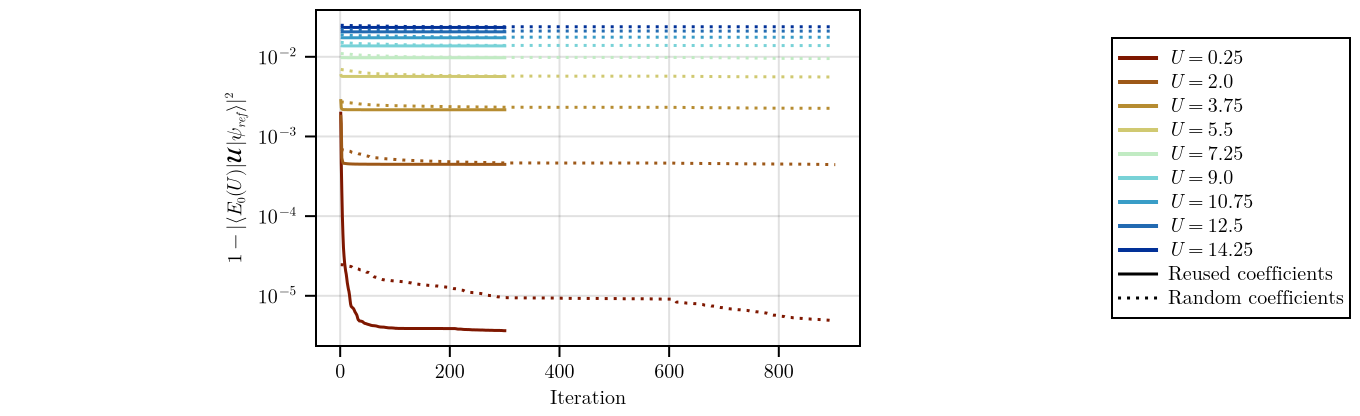

CairoMakie.Screen{IMAGE}


In [148]:
# loss curves

electrons = (4, 4)
site_dim = (3, 3)
u_indices = 2:7:60

fig, ax = create_fig(2;
    xlabel="Iteration",
    ylabel=L"1-|\langle E_0(U)|\mathcal{U}|\psi_{ref}\rangle|^2",
    yscale=log10,
)

colors = cmap1(length(u_indices))

# Solid lines: reused coefficients
reused_lines = []
for (c_i, u_idx) in enumerate(u_indices)
    filepath = data_folder("N=$(electrons)_$(join(site_dim, "x"))/$(build_save_name_prefix(:trotter;sites=prod(site_dim),antihermitian=true, custom_ref_state_arg="slater"))_u_$u_idx.jld2")
    dict = load_saved_dict(filepath)
    l = lines!(ax, dict["metrics"]["optimization_losses"][1];
        color=colors[c_i],
        label=L"U=%$((u_idx-1)*0.25)")
    push!(reused_lines, l)
end

# Dotted lines: random coefficients (separate folder)
for (c_i, u_idx) in enumerate(u_indices)
    filepath = data_folder("N=$(electrons)_$(join(site_dim, "x"))_separate/$(build_save_name_prefix(:trotter;sites=prod(site_dim),antihermitian=true, custom_ref_state_arg="slater"))_u_$u_idx.jld2")
    dict = load_saved_dict(filepath)
    lines!(ax, dict["metrics"]["optimization_losses"][1];
        color=colors[c_i], linestyle=:dot)
end

# Legend entries for line styles
solid_elem = LineElement(color=:black, linestyle=:solid)
dot_elem   = LineElement(color=:black, linestyle=:dot)

# Build per-U legend entries
u_entries = [LineElement(color=colors[i], linewidth=2) for i in eachindex(u_indices)]
u_labels  = [L"U=%$((u_idx-1)*0.25)" for u_idx in u_indices]

Legend(fig[1, 2],
    [u_entries..., solid_elem, dot_elem],
    [u_labels..., "Reused coefficients", "Random coefficients"]; LEGEND_ARGS...)

# mkpath("good_images/final/extra")
# save("good_images/final/extra/loss_curve_(4,4)_3x3.png", fig)
# save("good_images/final/extra/loss_curve_(4,4)_3x3.pdf", fig)
display(fig)

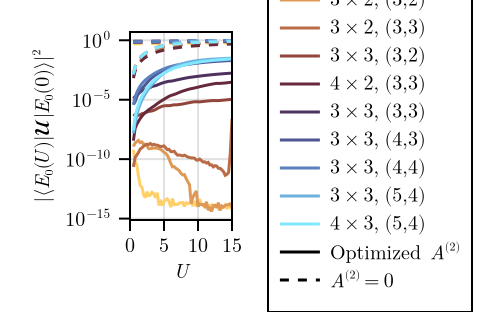

CairoMakie.Screen{IMAGE}


In [86]:
fig_overlap = Figure(size=get_figsize(1))
ax_overlap = Axis(fig_overlap[1, 1];
    xlabel = L"U",
    ylabel = L"|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2",
    limits = ((0, 15),(nothing, nothing)),
    yscale = log10
)

hilbert_space_sizes = []
final_performances = []
num_tuning_parameters = []

u_indices = 2:60
palette_colors = cmap2(length(FILE_LABEL_PAIRS))


selected_u_indices = [20, 30, 45]
palette_colors2 = cmap2(length(selected_u_indices))

for (sys_idx, (display_label, file_label, electron_counts)) in enumerate(FILE_LABEL_PAIRS)
    sys_dir = joinpath(FOLDER, file_label)
    if !isdir(sys_dir)
        @warn "Directory for system $file_label does not exist: $sys_dir. Skipping."
        continue
    end

    num_sites = prod(parse_lattice_dimension(file_label))
    prefix = build_save_name_prefix(:trotter;
        electrons = electron_counts, sites = num_sites,
        antihermitian = true, custom_ref_state_arg = "slater")

    meta_file = joinpath(sys_dir, "meta_data_and_E.jld2")
    if isfile(meta_file)
        metadata_dict = load(meta_file)["dict"]
        hilbert_space_size = size(metadata_dict["all_full_eig_vecs"][1], 2)
        interaction_data = metadata_dict["meta_data"]["U_values"]
    else
        valid_files = [f for f in readdir(sys_dir) if occursin("HubbardED", f)]
        if isempty(valid_files)
            @warn "No meta_data_and_E.jld2 or HubbardED HDF5 files found in $sys_dir. Skipping."
            continue
        end
        interaction_data = nothing
        hilbert_space_size = nothing
        h5open(joinpath(sys_dir, valid_files[1]), "r") do h5data
            global interaction_data = read(h5data["data/uvec"])
            global hilbert_space_size = length(read(h5data["data/evecs/0"])[:, 1, 1])
        end
    end
    
    coefficients_list = []
    optimized_overlaps = Float64[]
    second_order_overlaps = Float64[]
    baseline_overlaps = Float64[]

    valid_u_indices = Int[]
    for u_idx in u_indices
        filepath = joinpath(sys_dir, "$(prefix)_u_$(u_idx).jld2")
        if !isfile(filepath)
            continue
        end
        result_dict = load_saved_dict(filepath)

        push!(valid_u_indices, u_idx)
        push!(coefficients_list, result_dict["coefficients"][2])
        # println(result_dict["metrics"]["loss"]," ", file_label, " ", u_idx)
        push!(optimized_overlaps, result_dict["metrics"]["loss"][2])
        if length(result_dict["metrics"]["loss"]) > 2
            push!(second_order_overlaps, result_dict["metrics"]["loss"][3])
        end
        push!(baseline_overlaps, result_dict["metrics"]["loss"][1])
    end
    # println(baseline_overlaps)

    if isempty(valid_u_indices)
        @warn "No valid optimization files found for $file_label. Skipping."
        continue
    end

    coef_matrix = reduce(hcat, coefficients_list)

    # Coefficient trajectory plot
    fig_trajectory = Figure()
    ax_trajectory = Axis(fig_trajectory[1, 1];
        xlabel = L"U",
        ylabel = L"A^{(2)} \;\textrm{value}",
        limits = ((0, 10), (-0.5, 0.5)),
    )
    for col in eachcol(coef_matrix)
        lines!(ax_trajectory, interaction_data[valid_u_indices], col; color = (:royalblue1, 0.06))
    end
    for (color_idx, u_idx) in enumerate(selected_u_indices)
        if u_idx in valid_u_indices
            vlines!(ax_trajectory, [interaction_data[u_idx]];
                color = palette_colors2[color_idx], linestyle = :dash,
                label = L"U=%$(round(interaction_data[u_idx], digits=2))")
        end
    end
    axislegend(ax_trajectory; position = :rt, backgroundcolor = (:white, 0.8))

    # Main overlap curves
    lines!(ax_overlap, interaction_data[valid_u_indices], baseline_overlaps;
        color = palette_colors[sys_idx], linestyle = :dash)
    lines!(ax_overlap, interaction_data[valid_u_indices], optimized_overlaps;
        color = palette_colors[sys_idx], label = string(display_label))

 
end

# Style legend entries for main overlap figure
lines!(ax_overlap, [NaN], [NaN];
    color = :black, linestyle = :solid,
    label = L"\textrm{Optimized}\;\,A^{(2)} ")
lines!(ax_overlap, [NaN], [NaN];
    color = :black,linestyle = :dash,
    label = L"A^{(2)}=0")

Legend(fig_overlap[1,2], ax_overlap, rowgap=-6)
# axislegend(ax_overlap; position = :lb, backgroundcolor = (:white, 0.8))

display(fig_overlap)
# save("good_images/final/extra/relative_loss.png", fig_main)
# save("good_images/final/extra/relative_loss.pdf", fig_main)
# save("good_images/final/extra/loss_improvement2.png", fig_sub)
# save("good_images/final/extran/loss_improvement2.pdf", fig_sub)


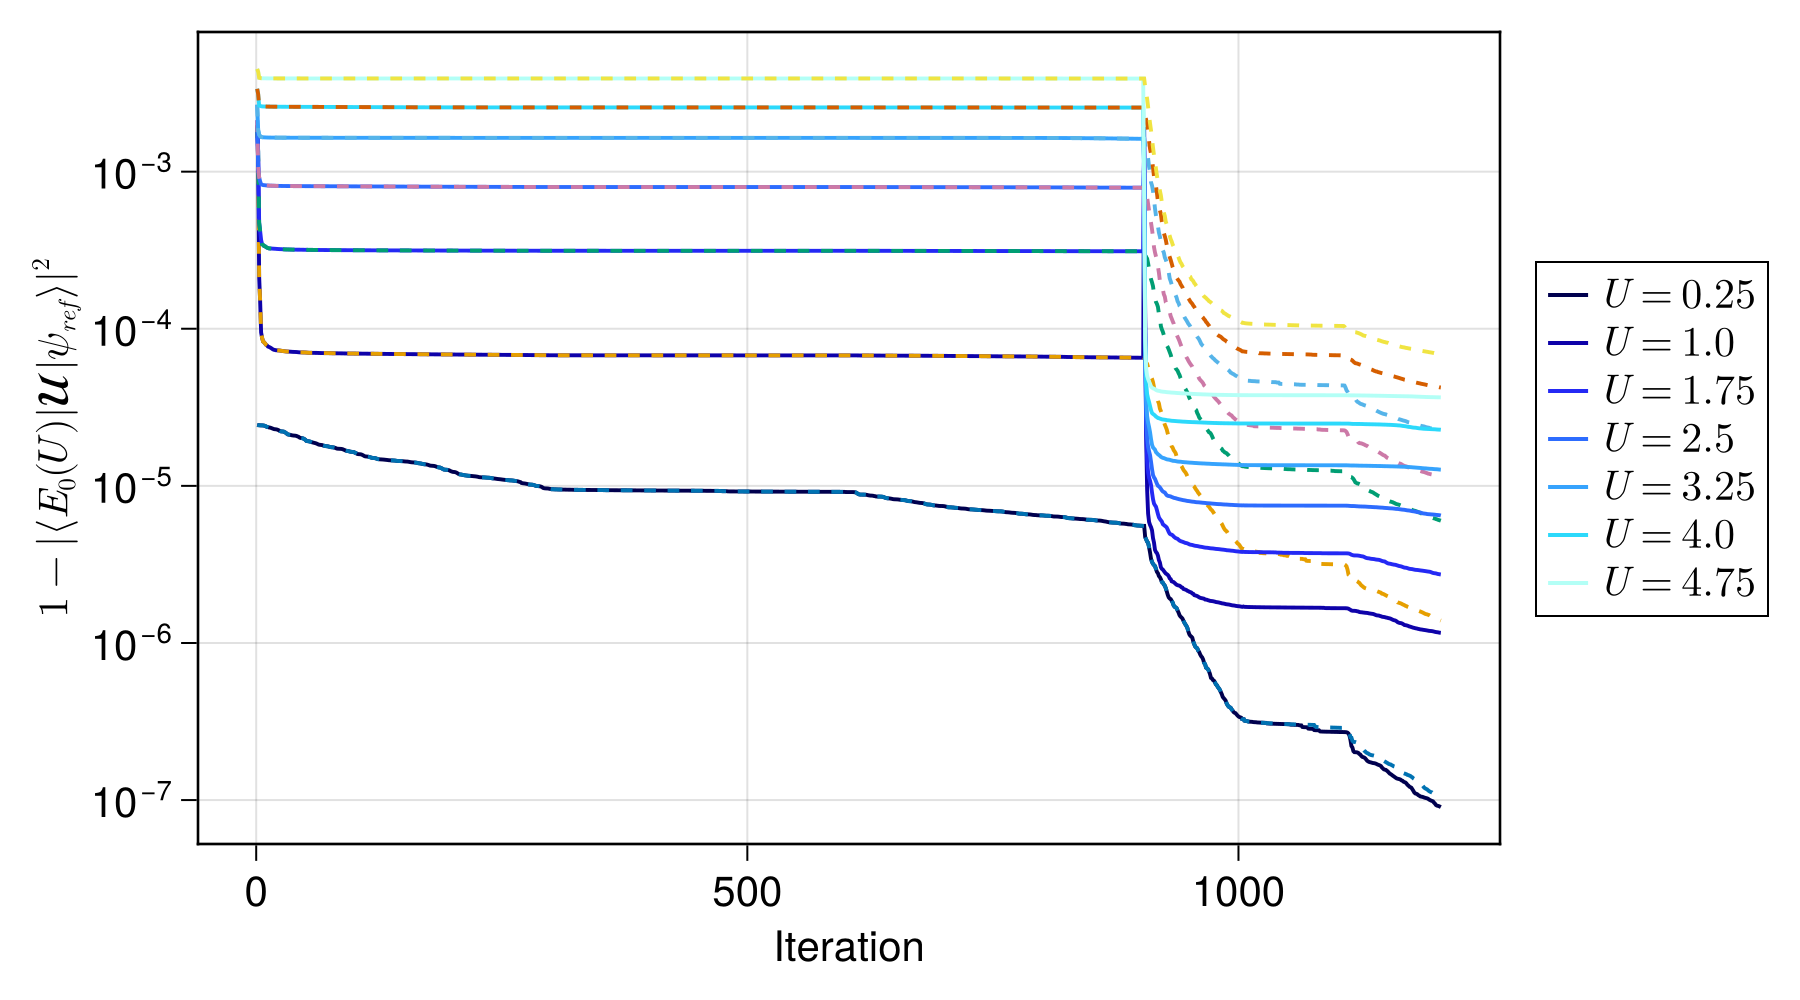

CairoMakie.Screen{IMAGE}


In [ ]:
# loss curves when adding an extra num_exponential

electrons = (4, 4)
site_dim = (3, 3)
u_indices = 2:3:20

fig = Figure(size=(900, 500))
ax = Axis(fig[1, 1];
    xlabel="Iteration",
    ylabel=L"1-|\langle E_0(U)|\mathcal{U}|\psi_{ref}\rangle|^2",
    yscale=log10,
)

colors = cmap1(length(u_indices))


for (c_i, u_idx) in enumerate(u_indices)
    filename_prefix = build_save_name_prefix(:trotter;
        sites=prod(site_dim),
        antihermitian=true, 
        custom_ref_state_arg="slater",
         num_exponentials=1,
        )
    filepath = data_folder("N=$(electrons)_$(join(site_dim, "x"))/$(filename_prefix)_u_$u_idx.jld2")
    dict = load_saved_dict(filepath)

    filename_prefix = build_save_name_prefix(:trotter;
        sites=prod(site_dim),
        antihermitian=true, 
        custom_ref_state_arg="slater",
         num_exponentials=2,
        )
    filepath = data_folder("N=$(electrons)_$(join(site_dim, "x"))/$(filename_prefix)_u_$u_idx.jld2")
    dict2 = load_saved_dict(filepath)

        filename_prefix = build_save_name_prefix(:trotter;
        sites=prod(site_dim),
        antihermitian=true, 
        custom_ref_state_arg="slater",
         num_exponentials=2,
         suffix="u_build"
        )
    filepath = data_folder("N=$(electrons)_$(join(site_dim, "x"))/$(filename_prefix)_u_$u_idx.jld2")
    dict3 = load_saved_dict(filepath)
    l = lines!(ax, [dict["metrics"]["optimization_losses"][1];dict2["metrics"]["optimization_losses"][1]];
        color=colors[c_i],
        label=L"U=%$((u_idx-1)*0.25)")
    l = lines!(ax, [dict["metrics"]["optimization_losses"][1];dict3["metrics"]["optimization_losses"][1]];
        label=L"U=%$((u_idx-1)*0.25)", linestyle=:dash)
end


# Build per-U legend entries
u_entries = [LineElement(color=colors[i], linewidth=2) for i in eachindex(u_indices)]
u_labels  = [L"U=%$((u_idx-1)*0.25)" for u_idx in u_indices]

Legend(fig[1, 2],
    [u_entries...],
    [u_labels...])


display(fig)

# Continuity of coefficients

In [34]:
filename_prefix = build_save_name_prefix(:trotter;
    sites=prod(site_dim),
    antihermitian=true, 
    custom_ref_state_arg="slater",
    num_exponentials=2,
    suffix="u_build"
)

coefs = []
for u_idx in 2:15
    filepath = data_folder("N=$(electrons)_$(join(site_dim, "x"))/$(filename_prefix)_u_$u_idx.jld2")
    dict = load_saved_dict(filepath)
    push!(coefs, dict["coefficients"])
end
println(length(coefs[1]))
[maximum(abs.(coefs[i+1] - coefs[i])) for i=1:10]


864


10-element Vector{Float64}:
 0.26149982900970936
 0.14504897816108414
 0.2548050949520976
 0.26008633922270524
 0.3212918872768566
 0.2624869174032506
 0.49228644935092597
 0.518928261876199
 0.7579919505238837
 0.4212499445439922

# Pruning curves

Using width=7.086614173228347" and height=2.7559055118110236"


[0.4999089971486379, 0.49963644355803005, 0.4991838606045542, 0.4985538653237518, 0.4977501266477721, 0.496777304789362, 0.4956409757158593, 0.49434754306802897, 0.4929041401713754, 0.49131852495339856, 0.48959897061948043, 0.4877541548609772, 0.4857930501865322, 0.48372481770123743, 0.4815587063303891, 0.47930395911837054, 0.4769697278508014, 0.474564996869393, 0.47209851659048063, 0.46957874691269585, 0.46701381041553547, 0.46441145501367154, 0.46177902554348405, 0.45912344361745294, 0.45645119498554343, 0.45376832358601193, 0.451080431445557, 0.4483926835946547, 0.44570981719227265, 0.44303615409952557, 0.44037561619905796, 0.4377317428217713, 0.4351077097111685, 0.4325063490251536, 0.42993016994324373, 0.4273813795121164, 0.4248619034230201, 0.4223734064700355, 0.41991731248812414, 0.4174948236141496, 0.4151069387527586, 0.41275447116234143, 0.4104380651046574, 0.40815821152547893, 0.40591526275325496, 0.4037094462187566, 0.40154087721141873, 0.39940957069802563, 0.3973154522369384

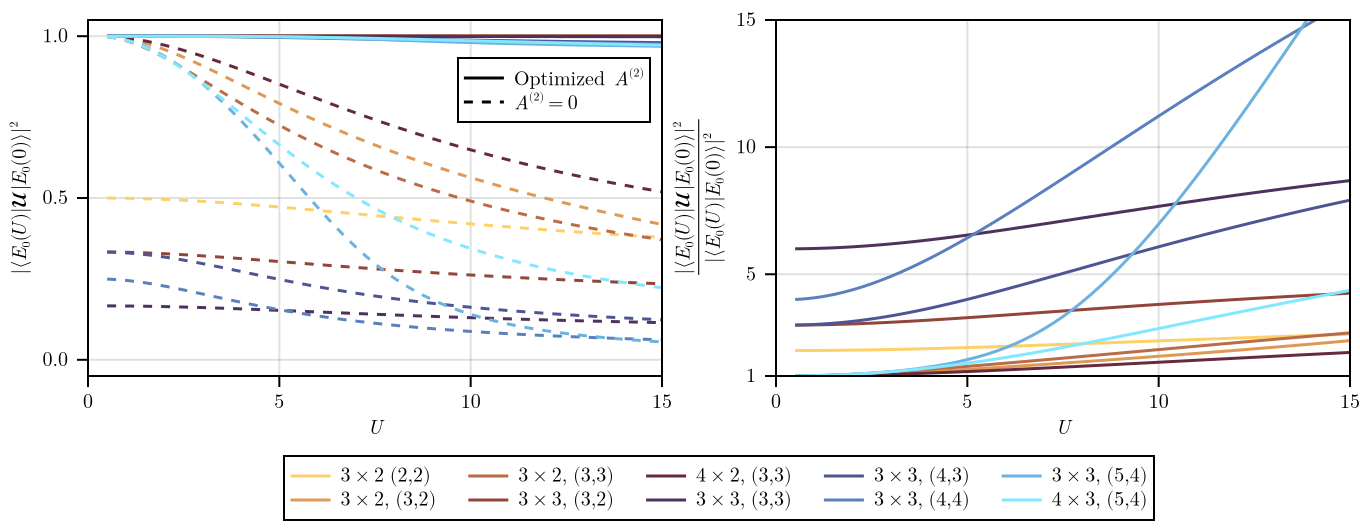

CairoMakie.Screen{PDF}


In [149]:
fig_overlap, ax_overlap = create_fig(2, 70.0;
    xlabel = L"U",
    ylabel = L"|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2",
    limits = ((0, 15), (-0.05, 1.05)),
)

# fig_improvement = Figure()
ax_improvement = Axis(fig_overlap[1, 2];
    aspect = (1+sqrt(5))/2,
    xlabel = L"U",
    ylabel = L"\frac{|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2}{|\langle E_0(U)|E_0(0)\rangle|^2}",
    limits = ((0, 15), (1, 15)),
    yticks = [1,5,10,15]
)

hilbert_space_sizes = []
final_performances = []
num_tuning_parameters = []

u_indices = 2:60
palette_colors = cmap2(length(FILE_LABEL_PAIRS))


selected_u_indices = [20, 30, 45]
palette_colors2 = cmap2(length(selected_u_indices))

for (sys_idx, (display_label, file_label, electron_counts)) in enumerate(FILE_LABEL_PAIRS)
    sys_dir = joinpath(FOLDER, file_label)
    if !isdir(sys_dir)
        @warn "Directory for system $file_label does not exist: $sys_dir. Skipping."
        continue
    end

    num_sites = prod(parse_lattice_dimension(file_label))
    prefix = build_save_name_prefix(:trotter;
        electrons = electron_counts, sites = num_sites,
        antihermitian = true, custom_ref_state_arg = "slater")

    meta_file = joinpath(sys_dir, "meta_data_and_E.jld2")
    if isfile(meta_file)
        metadata_dict = load(meta_file)["dict"]
        hilbert_space_size = size(metadata_dict["all_full_eig_vecs"][1], 2)
        interaction_data = metadata_dict["meta_data"]["U_values"]
    else
        valid_files = [f for f in readdir(sys_dir) if occursin("HubbardED", f)]
        if isempty(valid_files)
            @warn "No meta_data_and_E.jld2 or HubbardED HDF5 files found in $sys_dir. Skipping."
            continue
        end
        interaction_data = nothing
        hilbert_space_size = nothing
        h5open(joinpath(sys_dir, valid_files[1]), "r") do h5data
            global interaction_data = read(h5data["data/uvec"])
            global hilbert_space_size = length(read(h5data["data/evecs/0"])[:, 1, 1])
        end
    end

    coefficients_list = []
    optimized_overlaps = Float64[]
    second_order_overlaps = Float64[]
    baseline_overlaps = Float64[]

    valid_u_indices = Int[]
    for u_idx in u_indices
        filepath = joinpath(sys_dir, "$(prefix)_u_$(u_idx).jld2")
        if !isfile(filepath)
            continue
        end
        result_dict = load_saved_dict(filepath)

        push!(valid_u_indices, u_idx)
        push!(coefficients_list, result_dict["coefficients"][2])
        push!(optimized_overlaps, 1 - result_dict["metrics"]["loss"][2])
        if length(result_dict["metrics"]["loss"]) > 2
            push!(second_order_overlaps, 1 - result_dict["metrics"]["loss"][3])
        end
        push!(baseline_overlaps, 1 - result_dict["metrics"]["loss"][1])
    end
    println(baseline_overlaps)

    if isempty(valid_u_indices)
        @warn "No valid optimization files found for $file_label. Skipping."
        continue
    end

    coef_matrix = reduce(hcat, coefficients_list)

    # Coefficient trajectory plot
    fig_trajectory = Figure()
    ax_trajectory = Axis(fig_trajectory[1, 1];
        xlabel = L"U",
        ylabel = L"A^{(2)} \;\textrm{value}",
        limits = ((0, 10), (-0.5, 0.5)),
    )
    for col in eachcol(coef_matrix)
        lines!(ax_trajectory, interaction_data[valid_u_indices], col; color = (:royalblue1, 0.06))
    end
    for (color_idx, u_idx) in enumerate(selected_u_indices)
        if u_idx in valid_u_indices
            vlines!(ax_trajectory, [interaction_data[u_idx]];
                color = palette_colors2[color_idx], linestyle = :dash,
                label = L"U=%$(round(interaction_data[u_idx], digits=2))")
        end
    end
    axislegend(ax_trajectory; position = :rt, backgroundcolor = (:white, 0.8))

    # Main overlap curves
    lines!(ax_overlap, interaction_data[valid_u_indices], baseline_overlaps;
        color = palette_colors[sys_idx], linestyle = :dash)
    lines!(ax_overlap, interaction_data[valid_u_indices], optimized_overlaps;
        color = palette_colors[sys_idx]#, label = string(display_label)
        )

    # Improvement ratios
    overlap_improvement_ratios = optimized_overlaps ./ baseline_overlaps
    target_u_val = 10
    lines!(ax_improvement, interaction_data[valid_u_indices], overlap_improvement_ratios;
        color = palette_colors[sys_idx], label = string(display_label))

    target_idx = argmin(abs.(interaction_data .- target_u_val)) + valid_u_indices[1] - 1
    push!(final_performances, overlap_improvement_ratios[min(target_idx, length(overlap_improvement_ratios))])
    push!(hilbert_space_sizes, hilbert_space_size)

    dimension_match = match(r"(?<N>\d+)[xX](?<M>\d+)", file_label)
    push!(num_tuning_parameters, get_num_2nd_order_coef(
        parse(Int, dimension_match[:N]),
        parse(Int, dimension_match[:M])
    ))

    # Histogram at selected U values
    # for (color_idx, u_idx) in enumerate(selected_u_indices)
    #     filepath = joinpath(sys_dir, "$(prefix)_u_$(u_idx).jld2")
    #     if !isfile(filepath)
    #         continue
    #     end
    #     result_dict = load_saved_dict(filepath)
    #     coef_values = result_dict["coefficients"]
    #     if length(coef_values) < 5
    #         coef_values = coef_values[2]
    #     end

        # fig_histogram = Figure()
        # ax_histogram = Axis(fig_histogram[1, 1];
        #     xlabel = L"A^{(2)}\;\textrm{value}",
        #     ylabel = L"\textrm{Count}",
        #     limits = ((-0.5, 0.5), (0, nothing)),
        #     xticks = -0.5:0.25:0.5,
        # )
        # hist!(ax_histogram, coef_values;
        #     bins = LinRange(-0.5, 0.5, 50),
        #     color = palette_colors[color_idx],
        #     label = L"U=%$(round(interaction_data[u_idx], digits=2))", strokewidth=2)
        # axislegend(ax_histogram; position = :rt, backgroundcolor = (:white, 0.8))
        # display(fig_histogram)

        # mkpath("good_images/antihermitian")
        # save("good_images/antihermitian/U=$(round(interaction_data[u_idx], digits=2))_$(file_label)_histogram.png", fig_histogram)
        # save("good_images/antihermitian/U=$(round(interaction_data[u_idx], digits=2))_$(file_label)_histogram.pdf", fig_histogram)
    # end
end

# Style legend entries for main overlap figure
lines!(ax_overlap, [NaN], [NaN];
    color = :black, linestyle = :solid,
    label = L"\textrm{Optimized}\;\,A^{(2)} ")
lines!(ax_overlap, [NaN], [NaN];
    color = :black,linestyle = :dash,
    label = L"A^{(2)}=0")

Legend(fig_overlap[2,1:2], ax_improvement, orientation=:horizontal, nbanks=2; LEGEND_ARGS...)
# Legend(fig_improvement[1,3], ax_improvement)
axislegend(ax_overlap; backgroundcolor = (:white, 0.8), position=(1,0.9),LEGEND_ARGS...)
# axislegend(ax_improvement; position = :lt, backgroundcolor = (:white, 0.8))
rowgap!(fig_overlap.layout, 5)
colgap!(fig_overlap.layout, 5)
display(fig_overlap)
# display(fig_improvement)

save("good_images/final/loss_curve.png", fig_overlap)
save("good_images/final/loss_curve.pdf", fig_overlap)
# save("good_images/final/extra/loss_improvement2.png", fig_sub)
# save("good_images/final/extran/loss_improvement2.pdf", fig_sub)


In [8]:
function find_root_bisection(f, a, b; tol=1e-5, max_iters=100)
    fa = f(a)
    fb = f(b)
    if sign(fa) == sign(fb)
        return NaN
    end
    for _ in 1:max_iters
        c = (a + b) / 2
        fc = f(c)
        if abs(fc) < tol || (b - a) / 2 < tol
            return c
        end
        if sign(fc) == sign(fa)
            a = c
            fa = fc
        else
            b = c
            fb = fc
        end
    end
    return (a + b) / 2
end


function plot_pruning_curves(
    interaction_data,
    u_indices,
    file_label_pair,
    fit_params2,
    rescaling_vals,
    sys_x_filt2,
    sys_y_filt2,
    output_dir::String,
    antihermitian_val::Bool,
    custom_ref_state_arg_val,
    cmap;
    selected_U=8
)
    pruning_plot_u_idx = argmin(abs.(interaction_data[u_indices] .- selected_U)) + u_indices[1] - 1

    fig, ax = create_fig(1, 70.0;
        xlabel = L"\textrm{Sparsity}",
        ylabel = L"|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2",
        yticks = 0:0.1:1,
        xticks = 0:0.25:1,
    )

    plot_idx_local = findfirst(==(pruning_plot_u_idx), u_indices)

    for (color_i, (label, _, _)) in enumerate(file_label_pair)
        if !isnothing(plot_idx_local)
            fit_p = fit_params2[color_i][plot_idx_local]
            rescale_p = rescaling_vals[color_i][plot_idx_local]
            x_pts = sys_x_filt2[color_i][plot_idx_local]
            y_pts = sys_y_filt2[color_i][plot_idx_local]

            lines!(ax, LinRange(0, 1, 200), rescale(model(LinRange(0, 1, 200), fit_p), rescale_p);
                color = cmap[color_i], linestyle = :dash)
            scatter!(ax, x_pts, rescale(y_pts, rescale_p);
                color = cmap[color_i], label = string(label))
        end
    end
    axislegend(ax; position = :lb, backgroundcolor = (:white, 0.8))

    println("U=$(interaction_data[pruning_plot_u_idx])")

    u_val_str = round(interaction_data[pruning_plot_u_idx], digits=2)
    out_filename = build_save_name_prefix(
        "U=$(u_val_str)_pruning_curve";
        antihermitian=antihermitian_val,
        custom_ref_state_arg=custom_ref_state_arg_val
    )
    save(joinpath(output_dir, "$(out_filename).pdf"), fig)
    save(joinpath(output_dir, "$(out_filename).png"), fig)

    display(fig)
    return fig
end

"""
    plot_sparsity_at_threshold(interaction_data, u_indices, file_label_pair, fit_params2, rescaling_vals, hilbert_space_sizes, output_dir, antihermitian_val, custom_ref_state_arg_val, cmap; threshold=0.998)

Calculation 2: Calculate and plot maximum sparsity achieved at overlap `threshold` across interaction strength U.
"""
function plot_sparsity_at_threshold(
    interaction_data,
    u_indices,
    file_label_pair,
    fit_params2,
    rescaling_vals,
    hilbert_space_sizes,
    output_dir::String,
    antihermitian_val::Bool,
    custom_ref_state_arg_val,
    cmap;
    threshold=0.998
)
    x_thresholds = []
    fig, ax = create_fig(1, 70.0;
        xlabel = L"U",
        ylabel = L"$\textrm{Max\;sparsity\;at\;threshold\;}$\\$|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2 \geq %$(threshold)$",
        limits = ((0, 15), (0, 1)),
        yticks = 0:0.1:1,
    )

    for (i, (param_u, (label, _, _), rsc_vals, hs_size)) in enumerate(zip(fit_params2, file_label_pair, rescaling_vals, hilbert_space_sizes))
        push!(x_thresholds, Float64[])
        for (param, rsc_val) in zip(param_u, rsc_vals)
            x_val = find_root_bisection(x -> rescale(model(x, param), rsc_val) - threshold, -1.0, 2.0)
            push!(x_thresholds[end], x_val)
        end
        scatterlines!(ax, interaction_data[u_indices], x_thresholds[end];
            label = string(label), linewidth = 2, markersize = 8, color = cmap[i])
    end
    Legend(fig[1, 2], ax; LEGEND_ARGS...)

    out_filename = build_save_name_prefix(
        "pruning_data_overlap_threshold_$(threshold)";
        antihermitian=antihermitian_val,
        custom_ref_state_arg=custom_ref_state_arg_val
    )
    save(joinpath(output_dir, "$(out_filename).pdf"), fig)
    save(joinpath(output_dir, "$(out_filename).png"), fig)
    println(joinpath(output_dir, "$(out_filename).png"))
    display(fig)
    return fig
end

"""
    plot_sparsity_inflection_points(interaction_data, u_indices, file_label_pair, fit_params2, fit_errors2, rescaling_vals, hilbert_space_sizes, output_dir, antihermitian_val, custom_ref_state_arg_val, cmap; use_ribbon=false, max_error=0.8, min_u_spacing=0.5)

Calculation 3: Plot sparsity inflection points (fitted parameter `p[2]`) with standard error bars (`stderror`) across interaction strength U.
Strides error bars based on minimum physical distance in U space (`min_u_spacing`) to ensure clean spacing on the linear U axis.
"""
function plot_sparsity_inflection_points(
    interaction_data,
    u_indices,
    file_label_pair,
    fit_params2,
    fit_errors2,
    rescaling_vals,
    hilbert_space_sizes,
    output_dir::String,
    antihermitian_val::Bool,
    custom_ref_state_arg_val,
    cmap;
    use_ribbon::Bool=false,
    max_error::Float64=0.8,
    min_u_spacing::Float64=0.1
)
    fig, ax = create_fig(1, 70.0;
        xlabel = L"U",
        ylabel = L"\textrm{sparsity\;\,inflection\;\,point}",
        limits = ((0, 15), (0, 1)),
        yticks = 0:0.1:1,
    )

    for (i, (param_u, err_u, (label, _, _), rsc_vals, hs_size)) in enumerate(zip(fit_params2, fit_errors2, file_label_pair, rescaling_vals, hilbert_space_sizes))
        u_vals = interaction_data[u_indices]
        x_inflections = Float64[]
        x_inflection_errors = Float64[]

        for (param, errs) in zip(param_u, err_u)
            push!(x_inflections, param[2])
            val_err = (length(errs) >= 2 && !isnan(errs[2]) && !isinf(errs[2])) ? errs[2] : 0.0
            # Clamp unphysically large covariance errors from ill-conditioned fits at low U
            val_err = min(val_err, max_error)
            push!(x_inflection_errors, val_err)
        end

        if use_ribbon
            band!(ax, u_vals, x_inflections .- x_inflection_errors, x_inflections .+ x_inflection_errors;
                color = (cmap[i], 0.3))
            lines!(ax, u_vals, x_inflections; label = string(label), linewidth = 2, color = cmap[i])
        else
            # Draw primary trend curve
            lines!(ax, u_vals, x_inflections; label = string(label), linewidth = 2, color = cmap[i])

            # Subsample error bars based on linear distance in U space
            sub_indices = Int[]
            last_u = -Inf
            for (k, u_val) in enumerate(u_vals)
                if u_val - last_u >= min_u_spacing
                    push!(sub_indices, k)
                    last_u = u_val
                end
            end

            errorbars!(ax, u_vals[sub_indices], x_inflections[sub_indices], x_inflection_errors[sub_indices];
                color = cmap[i], whiskerwidth = 6)
            scatter!(ax, u_vals[sub_indices], x_inflections[sub_indices];
                color = cmap[i], markersize = 8)
        end
    end
    axislegend(ax; position = :rb, backgroundcolor = (:white, 0.8))

    out_filename = build_save_name_prefix(
        "pruning_data_inflection_point";
        antihermitian=antihermitian_val,
        custom_ref_state_arg=custom_ref_state_arg_val
    )
    # save(joinpath(output_dir, "$(out_filename).pdf"), fig)
    # save(joinpath(output_dir, "$(out_filename).png"), fig)
    println(joinpath(output_dir, "$(out_filename).png"))
    display(fig)
    return fig
end

"""
    plot_pruning_and_sparsity_at_threshold(interaction_data, u_indices, file_label_pair, fit_params2, rescaling_vals, sys_x_filt2, sys_y_filt2, hilbert_space_sizes, output_dir, antihermitian_val, custom_ref_state_arg_val, cmap; selected_U=8, threshold=0.95)

Plot pruning curves for `selected_U` (left panel) and maximum sparsity at overlap `threshold` (right panel) in a single figure using `create_fig`.
"""
function plot_pruning_and_sparsity_at_threshold(
    interaction_data,
    u_indices,
    file_label_pair,
    fit_params2,
    rescaling_vals,
    sys_x_filt2,
    sys_y_filt2,
    hilbert_space_sizes,
    output_dir::String,
    antihermitian_val::Bool,
    custom_ref_state_arg_val,
    cmap;
    selected_U=8,
    threshold=0.95
)
    fig, ax1 = create_fig(2, 70.0;
        xlabel = L"\textrm{Sparsity}",
        ylabel = L"|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2",
        yticks = 0:0.1:1,
        xticks = 0:0.25:1,
    )

    ax2 = Axis(fig[1, 2];
        aspect = (1+sqrt(5))/2,
        xlabel = L"U",
        ylabel = L"$\textrm{Max\;sparsity\;at\;threshold\;}$\\$|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2 \geq %$(threshold)$",
        limits = ((0, 15), (0, 1)),
        yticks = 0:0.1:1,
    )

    # Panel 1: Pruning curves for selected U
    pruning_plot_u_idx = argmin(abs.(interaction_data[u_indices] .- selected_U)) + u_indices[1] - 1
    plot_idx_local = findfirst(==(pruning_plot_u_idx), u_indices)

    for (color_i, (label, _, _)) in enumerate(file_label_pair)
        if !isnothing(plot_idx_local)
            fit_p = fit_params2[color_i][plot_idx_local]
            rescale_p = rescaling_vals[color_i][plot_idx_local]
            x_pts = sys_x_filt2[color_i][plot_idx_local]
            y_pts = sys_y_filt2[color_i][plot_idx_local]

            lines!(ax1, LinRange(0, 1, 200), rescale(model(LinRange(0, 1, 200), fit_p), rescale_p);
                color = cmap[color_i], linestyle = :dash)
            scatter!(ax1, x_pts, rescale(y_pts, rescale_p);
                color = cmap[color_i], label = string(label))
        end
    end

    # Panel 2: Max sparsity at threshold
    x_thresholds = []
    for (i, (param_u, (label, _, _), rsc_vals, hs_size)) in enumerate(zip(fit_params2, file_label_pair, rescaling_vals, hilbert_space_sizes))
        push!(x_thresholds, Float64[])
        for (param, rsc_val) in zip(param_u, rsc_vals)
            x_val = find_root_bisection(x -> rescale(model(x, param), rsc_val) - threshold, -1.0, 2.0)
            push!(x_thresholds[end], x_val)
        end
        scatterlines!(ax2, interaction_data[u_indices], x_thresholds[end];
            label = string(label), linewidth = 2, markersize = 8, color = cmap[i])
    end

    Legend(fig[1, 3], ax2; LEGEND_ARGS...)
    colgap!(fig.layout, 10)

    u_val_str = round(interaction_data[pruning_plot_u_idx], digits=2)
    out_filename = build_save_name_prefix(
        "pruning_and_sparsity_threshold_U=$(u_val_str)_th=$(threshold)";
        antihermitian=antihermitian_val,
        custom_ref_state_arg=custom_ref_state_arg_val
    )
    save(joinpath(output_dir, "$(out_filename).pdf"), fig)
    save(joinpath(output_dir, "$(out_filename).png"), fig)
    println(joinpath(output_dir, "$(out_filename).png"))
    display(fig)
    return fig
end


plot_pruning_and_sparsity_at_threshold

$3\times 2\;(2,2)$
ERROR: [99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.99999999999889, 99.9999999999855, 99.9999999999855, 99.9999999999855, 99.99999994928544, 99.99999994928544, 99.99999994840316, 99.99999994840316, 99.99999994840316, 99.99999937386248, 99.99999937386248, 99.99999937386248, 99.99999936934205, 99.99999001746698, 99.99999001746698, 99.99999133494462, 99.9999616555299, 99.99991702348426, 99.99970498597108, 99.99967191036471, 99.9989825859321, 99.99726739305892, 99.97791969311564, 99.97621752995069, 99.95281626445357, 99.95190112565543, 99.88979954847139, 99.83547618374983, 99.74673654117788, 99.3909346761838, 99.35945865374997, 98.09242704598863, 91.1529885

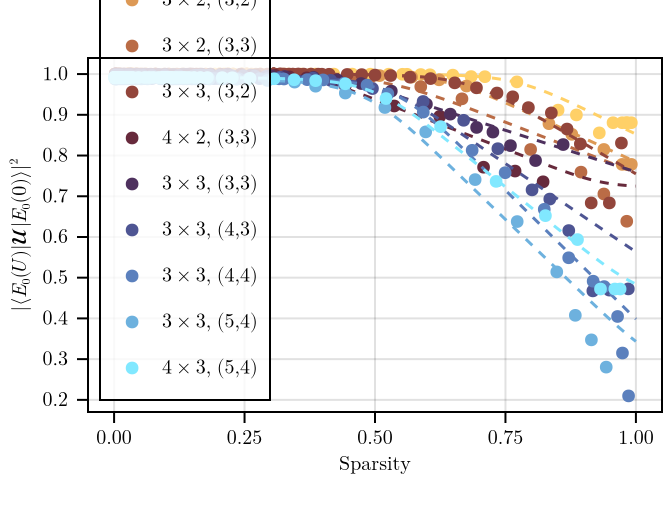

Using width=3.5039370078740157" and height=2.7559055118110236"
/home/jek354/research/ML-signproblem/experimenting/ed/good_images/final/pruning_data_overlap_threshold_0.95_ref_slater_antihermitian.png


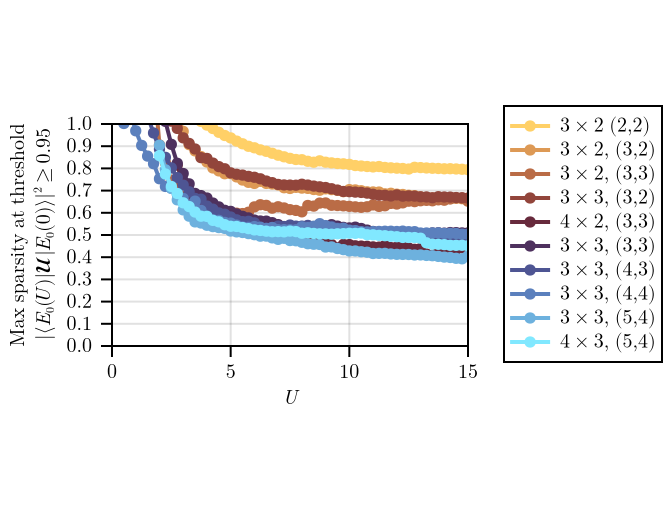

Using width=3.5039370078740157" and height=2.7559055118110236"
/home/jek354/research/ML-signproblem/experimenting/ed/good_images/final/pruning_data_inflection_point_ref_slater_antihermitian.png


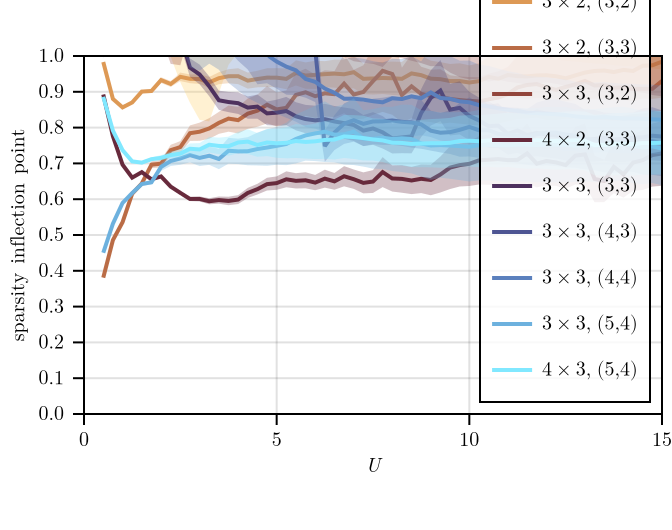

Using width=7.086614173228347" and height=2.7559055118110236"


LoadError: Failed to resolve [31marg1:[39m
[ComputeEdge] [31marg1[39m = compute_identity(([31mlinesgments_shifted[39m, ), changed, cached)
[90m  @ /home/jek354/.julia/packages/ComputePipeline/E2l50/src/ComputePipeline.jl:743[39m
[ComputeEdge] [31mlinesgments_shifted[39m = (::MapFunctionWrapper(#tex_linesegments!##0))(([31mlinesegments[39m, [90mlineindices[39m, [90mpreprojection[39m, [90mmodel_f32c[39m, [90mpositions_transformed_f32c[39m, [90mmodel_clip_planes[39m, [90mspace[39m, ), changed, cached)
[90m  @ unknown method location[39m
[ComputeEdge] [31mglyphcollections, glyphindices, font_per_char, glyph_origins, glyph_extents, text_blocks, text_color, text_rotation, text_scales, text_strokewidth, text_strokecolor, linesegments, linewidths, linecolors, lineindices[39m = #compute_glyph_collections!##0(([92minput_text[39m, [92mfontsize[39m, [92mselected_font[39m, [92malign[39m, [92mrotation[39m, [92mjustification[39m, [92mlineheight[39m, [92mword

In [9]:


softplus(x, b) = max(x, zero(x)) + log(b) + log1p(exp(-abs(x)) / b)
scaled_softplus(x, p1, p2) = 1 / log(1 + p2) * softplus(p1 * x, p2)
# model(x,p) = @. 1 - (p[6]*scaled_softplus(p[5]*(x-1), p[1], p[2]) + (1-p[6])*scaled_softplus(p[5]*(x-1), p[3], p[4]))
# model(x,p) = @. (1-tanh(p[1]*(x-p[2])))/2  # too rigid/symmetric for this curve's asymmetric shoulder (SSE ~0.29 vs ~0.004 below)
model(x, p) = @. (1 - p[1] * (x - p[2]) / (1 + abs(p[1] * (x - p[2]))^p[3])^(1 / p[3])) / 2

rescale(x, p) = @. x * (p[2] - p[1]) + p[1]

antihermitian_val, custom_ref_state_arg_val = true, "slater"

# Load reference metadata for U values
ref_file_label = FILE_LABEL_PAIRS[1][2]
interaction_data = 0.25:0.25:15.0

hilbert_space_sizes = Int[]
fit_params2 = []
fit_errors2 = []
rescaling_vals = []
sys_x_filt2 = []
sys_y_filt2 = []
u_indices = 2:60

for (color_i, (label, file_label, nelectrons)) in enumerate(FILE_LABEL_PAIRS)
    nsites = prod(parse_lattice_dimension(file_label))
    filename = build_save_name_prefix(
        "pruning_analysis_trotter";
        sites=nsites,
        antihermitian=antihermitian_val,
        custom_ref_state_arg=custom_ref_state_arg_val
    )
    pruning_analysis_path = joinpath(FOLDER, file_label, "$(filename).jld2")
    system_size = parse_lattice_dimension(file_label)
    meta_data_path = joinpath(FOLDER, file_label, "HubbardBasis_XDiag_$(system_size[1])x$(system_size[2])_nu_$(nelectrons[1])_nd_$(nelectrons[2]).h5")

    h5open(meta_data_path, "r") do data
        push!(hilbert_space_sizes, length(data["sectors/0/R_up_rep"][:]))
    end

    d = load(pruning_analysis_path)

    curr_fit_params = Vector{Any}(undef, length(u_indices))
    curr_fit_errors = Vector{Any}(undef, length(u_indices))
    curr_rescaling_vals = Vector{Any}(undef, length(u_indices))
    curr_x_filt2 = Vector{Any}(undef, length(u_indices))
    curr_y_filt2 = Vector{Any}(undef, length(u_indices))
    println(label)
    for (idx, i) in collect(enumerate(u_indices))
        filt = d["removed_terms"][:, i] .> 0
        if abs(interaction_data[i] - 8) < 0.1 
            println("ERROR: $((1 .- abs.(d["error_data"][:, i][filt])) .* 100)")
        end

        err = max.(abs.(d["error_data"][:, i][filt]), 1e-16)
        overlap = 1 .- err

        x = d["removed_terms"][:, i][filt] ./ maximum(d["removed_terms"][:, i][filt])
        y = (overlap .- overlap[end]) ./ (overlap[1] .- overlap[end])
        curr_rescaling_vals[idx] = [overlap[end], overlap[1]]

        filt2 = y .> y[end]

        weight = min.(1 ./ (1 .- overlap) .^ 2, 1e6)  # cap: max(err,1e-16) floor otherwise lets weight blow up to ~1e27 and makes curve_fit's normal equations singular
        # println(x[filt2])
        # println(y[filt2])
        # fig = Figure()
        # ax = Axis(fig[1,1], yscale=log10)
        # l1= lines!(ax, x[filt2], 1 .-y[filt2], label="data")
        # l2 = lines!(ax, x[filt2], 1 .-model(x[filt2],[6.0,1.0,1.0]), label="personal")
        fit = curve_fit(
            model,
            x[filt2],
            y[filt2],
            weight[filt2],
            [1.0, 1.0, 1.0],
            lower=[-Inf, -Inf, 0.1],
            upper=[Inf, Inf, 10.0]
        )

        # println(fit.param)
        # l3 = lines!(ax, x[filt2], 1 .-model(x[filt2],fit.param), label="fit")
        # Legend(fig[1,1], [l1, l2, l3], ["data","personal", "fit"])
        # display(fig)

        errs = try
            stderror(fit)
        catch
            zeros(length(fit.param))
        end

        curr_fit_params[idx] = copy(fit.param)
        curr_fit_errors[idx] = copy(errs)
        curr_x_filt2[idx] = x[filt2]
        curr_y_filt2[idx] = y[filt2]
    end

    push!(fit_params2, curr_fit_params)
    push!(fit_errors2, curr_fit_errors)
    push!(rescaling_vals, curr_rescaling_vals)
    push!(sys_x_filt2, curr_x_filt2)
    push!(sys_y_filt2, curr_y_filt2)
end

output_dir = joinpath(@__DIR__, "good_images", "final")
if !isdir(output_dir)
    mkpath(output_dir)
end

cmap = cmap2(length(FILE_LABEL_PAIRS))

# Calculation 1: Plot pruning curves for selected U
plot_pruning_curves(
    interaction_data, u_indices, FILE_LABEL_PAIRS, fit_params2,
    rescaling_vals, sys_x_filt2, sys_y_filt2, output_dir,
    antihermitian_val, custom_ref_state_arg_val, cmap; selected_U=8
)

# Calculation 2: Plot max sparsity at overlap threshold
plot_sparsity_at_threshold(
    interaction_data, u_indices, FILE_LABEL_PAIRS, fit_params2,
    rescaling_vals, hilbert_space_sizes, output_dir,
    antihermitian_val, custom_ref_state_arg_val, cmap; threshold=0.95
)

# Calculation 3: Plot sparsity inflection points
plot_sparsity_inflection_points(
    interaction_data, u_indices, FILE_LABEL_PAIRS, fit_params2,
    fit_errors2, rescaling_vals, hilbert_space_sizes, output_dir,
    antihermitian_val, custom_ref_state_arg_val, cmap, use_ribbon=true,
)

# Combined Calculation: Plot pruning curves and max sparsity at overlap threshold in a single figure
plot_pruning_and_sparsity_at_threshold(
    interaction_data, u_indices, FILE_LABEL_PAIRS, fit_params2,
    rescaling_vals, sys_x_filt2, sys_y_filt2, hilbert_space_sizes, output_dir,
    antihermitian_val, custom_ref_state_arg_val, cmap; selected_U=8, threshold=0.95
)


In [28]:
interaction_data

0.25:0.25:15.0

In [17]:
path = "/home/jek354/research/data/new_data/data_h5_fixed/N=(4, 3)_3x3/HubbardBasis_XDiag_3x3_nu_4_nd_3.h5"
h5open(path, "r") do data
    display(data["sectors/0/R_up_rep"][:])
end

1176-element Vector{UInt32}:
 0x0000000f
 0x0000000f
 0x0000000f
 0x0000000f
 0x0000000f
 0x0000000f
 0x0000000f
 0x0000000f
 0x0000000f
 0x0000000f
          ⋮
 0x00000066
 0x00000066
 0x00000066
 0x00000066
 0x00000066
 0x00000066
 0x00000066
 0x00000066
 0x00000066

# Sandbox


0.9995028061336335 2.907862445401116e-10


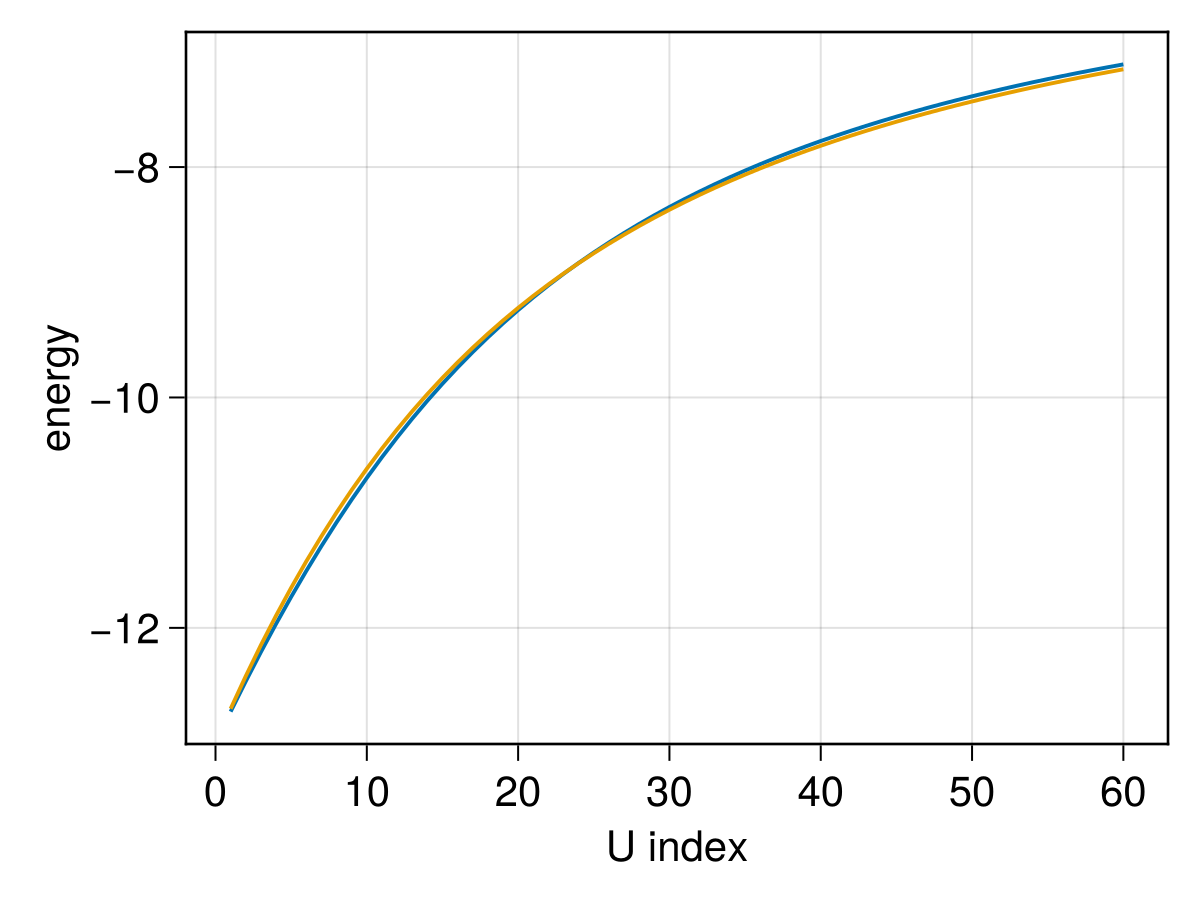

CairoMakie.Screen{IMAGE}


In [2]:
h5open(joinpath(FOLDER, "N=(4, 3)_3x3","HubbardED_XDiag_momSlater_3x3_nu_4_nd_3_t_1_m_2_sectors_(3).h5"), "r") do data
    # N = Tuple(convert.(Int, [read(data, "metadata/nu"), read(data, "metadata/nd")]))

    # Lvec = convert.(Int, read(data, "metadata/Lvec"))
    # U_values = Float64.(read(data, "data/uvec"))
    # kvecs = convert.(Int, read(data, "metadata/qvecs"))

    # key_labels = [parse(Int, k) for k in keys(data["data/energies"])]
    v1 = data["data/evecs/3"][:,1,:]
    v2 = data["data/evecs/3"][:,2,:]

    indices = select_continuous_state_indices(data["data/evecs/3"][:,:,:], data["data/energies/3"][:, :])
    energies = data["data/energies/3"][1, :]
    for i in axes(v1[:, end-1],2)
        println("$(abs(v1[:,i]'*v1[:, i+1])) $(abs(v1[:,i]'*v2[:, i+1]))")
    end
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel="U index", ylabel="energy")
    lines!(ax, [data["data/energies/3"][indices[i], i] for i in eachindex(indices)])
    lines!(ax, [data["data/energies/3"][3 - indices[i], i] for i in eachindex(indices)])
    display(fig)
    # all_E = [real.(read(data, "data/energies/$(k)"))[1, :] for k in key_labels]

    # display(plot(all_E[1]))
    # k_min = find_best_energy_sector(all_E, U_values; labels=key_labels, data=data, su2_symmetry=su2_symmetry)
end

# Slater Determinant Non-Interacting State Effects Analysis

In this section, we analyze the definitive effects of the existence of a unique, non-degenerate Slater determinant non-interacting state on the optimization performance.

We compare:
- **Systems containing Slater non-interacting state**:
  - $3\times 3$ $(5, 4)$ and $4\times 3$ $(5, 4)$
- **Systems NOT containing Slater non-interacting state**:
  - $3\times 3$ $(4, 4)$ and $4\times 3$ $(4, 4)$

We plot:
1. **Interaction loss as a function of $U$** for each of these systems. We make solid lines for the runs using the Slater reference state, and dashed lines for those that do not use it.
2. **Loss as a function of the Hilbert space size** at a selected U value ($U = 8.0$). We draw one line connecting the $(5, 4)$ systems (where the Slater non-interacting state exists, plotted as dashed line segments) and one connecting the $(4, 4)$ systems (where the Slater state does not exist, plotted as solid line segments) for both Slater and non-Slater reference runs. We also annotate the degrees of freedom (number of parameters) for each system.

In [ ]:
# Plot 1: Interaction loss as a function of U for the four systems.
# Solid for Slater reference, dashed for not-Slater.

using CairoMakie
using JLD2
using HDF5
using LaTeXStrings

const SYSTEMS_PLOT1 = [
    ("3x3 (5,4)", "N=(5, 4)_3x3", 9),
    ("4x3 (5,4)", "N=(5, 4)_4x3", 12),
    ("3x3 (4,4)", "N=(4, 4)_3x3", 9),
    ("4x3 (4,4)", "N=(4, 4)_4x3", 12)
]

fig1 = Figure(size=(1000, 600))
ax1 = Axis(fig1[1, 1],
    xlabel = L"U",
    ylabel = L"1 - |\langle E_0(U)|\mathcal{U}|\psi_{ref}\rangle|^2",
    yscale = log10,
    title = "Interaction Loss vs U"
)

colors1 = [:blue, :forestgreen, :crimson, :purple]
u_indices = 2:60

for (idx, (name, dir, sites)) in enumerate(SYSTEMS_PLOT1)
    sys_dir = joinpath(FOLDER, dir)
    if !isdir(sys_dir)
        continue
    end
    
    # 1. Slater reference run (solid)
    prefix_slater = "trotter_N=\$(sites)_ref_slater_antihermitian"
    u_vals_s = Float64[]
    losses_s = Float64[]
    for u_idx in u_indices
        f = joinpath(sys_dir, "\$(prefix_slater)_u_\$(u_idx).jld2")
        if isfile(f)
            d = load_saved_dict(f)
            push!(u_vals_s, (u_idx - 1) * 0.25)
            push!(losses_s, max(length(d["metrics"]["loss"]) >= 2 ? d["metrics"]["loss"][2] : d["metrics"]["loss"][1], 1e-12))
        end
    end
    
    # 2. Non-Slater reference run (dashed)
    prefix_noslater = "trotter_N=\$(sites)_antihermitian"
    u_vals_n = Float64[]
    losses_n = Float64[]
    for u_idx in u_indices
        f = joinpath(sys_dir, "\$(prefix_noslater)_u_\$(u_idx).jld2")
        if isfile(f)
            d = load_saved_dict(f)
            push!(u_vals_n, (u_idx - 1) * 0.25)
            push!(losses_n, max(length(d["metrics"]["loss"]) >= 2 ? d["metrics"]["loss"][2] : d["metrics"]["loss"][1], 1e-12))
        end
    end
    
    # Plot Slater (solid)
    if !isempty(losses_s)
        lines!(ax1, u_vals_s, losses_s, color=colors1[idx], linewidth=2.5, linestyle=:solid, label="\$name (Slater)")
    end
    # Plot non-Slater (dashed)
    if !isempty(losses_n)
        lines!(ax1, u_vals_n, losses_n, color=colors1[idx], linewidth=2.5, linestyle=:dash, label="\$name (No Slater)")
    end
end

axislegend(ax1, position=:rt, backgroundcolor=(:white, 0.8))
display(fig1)


In [ ]:
# Plot 2: Loss as a function of Hilbert space size for U = 8.0.

using CairoMakie
using JLD2
using HDF5
using LaTeXStrings

target_u_idx = 33 # corresponds to U = 8.0
target_u_val = (target_u_idx - 1) * 0.25

const SYSTEMS_PLOT2 = [
    ("3x3 (5,4)", "N=(5, 4)_3x3", 9, 1764, 504, true),
    ("4x3 (5,4)", "N=(5, 4)_4x3", 12, 32670, 1368, true),
    ("3x3 (4,4)", "N=(4, 4)_3x3", 9, 1764, 504, false),
    ("4x3 (4,4)", "N=(4, 4)_4x3", 12, 20439, 1368, false)
]

fig2 = Figure(size=(1000, 600))
ax2 = Axis(fig2[1, 1],
    xlabel = "Hilbert Space Size",
    ylabel = L"1 - |\langle E_0(U)|\mathcal{U}|\psi_{ref}\rangle|^2",
    yscale = log10,
    xscale = log10,
    title = "Loss vs Hilbert Space Size at U = \$target_u_val"
)
xlims!(ax2, 1000, 120000)

slater_exists_x_s = Float64[]
slater_exists_y_s = Float64[]
slater_noexists_x_s = Float64[]
slater_noexists_y_s = Float64[]

slater_exists_x_n = Float64[]
slater_exists_y_n = Float64[]
slater_noexists_x_n = Float64[]
slater_noexists_y_n = Float64[]

for (name, dir, sites, hs_size, dof, exists) in SYSTEMS_PLOT2
    sys_dir = joinpath(FOLDER, dir)
    if !isdir(sys_dir)
        continue
    end
    
    # 1. Slater reference
    f_s = joinpath(sys_dir, "trotter_N=\$(sites)_ref_slater_antihermitian_u_\$(target_u_idx).jld2")
    if isfile(f_s)
        d = load_saved_dict(f_s)
        loss_val = max(length(d["metrics"]["loss"]) >= 2 ? d["metrics"]["loss"][2] : d["metrics"]["loss"][1], 1e-12)
        if exists
            push!(slater_exists_x_s, hs_size)
            push!(slater_exists_y_s, loss_val)
        else
            push!(slater_noexists_x_s, hs_size)
            push!(slater_noexists_y_s, loss_val)
        end
        text!(ax2, hs_size, loss_val; text = "  \$name (dof=\$dof)", align = (:left, :center), fontsize = 12)
    end
    
    # 2. No Slater reference
    f_n = joinpath(sys_dir, "trotter_N=\$(sites)_antihermitian_u_\$(target_u_idx).jld2")
    if isfile(f_n)
        d = load_saved_dict(f_n)
        loss_val = max(length(d["metrics"]["loss"]) >= 2 ? d["metrics"]["loss"][2] : d["metrics"]["loss"][1], 1e-12)
        if exists
            push!(slater_exists_x_n, hs_size)
            push!(slater_exists_y_n, loss_val)
        else
            push!(slater_noexists_x_n, hs_size)
            push!(slater_noexists_y_n, loss_val)
        end
        text!(ax2, hs_size, loss_val; text = "  \$name (dof=\$dof)", align = (:left, :center), fontsize = 12)
    end
end

# Draw lines
if length(slater_exists_x_s) == 2
    p = sortperm(slater_exists_x_s)
    lines!(ax2, slater_exists_x_s[p], slater_exists_y_s[p], color=:blue, linestyle=:dash, linewidth=2.5)
end
if length(slater_noexists_x_s) == 2
    p = sortperm(slater_noexists_x_s)
    lines!(ax2, slater_noexists_x_s[p], slater_noexists_y_s[p], color=:blue, linestyle=:solid, linewidth=2.5)
end

if length(slater_exists_x_n) == 2
    p = sortperm(slater_exists_x_n)
    lines!(ax2, slater_exists_x_n[p], slater_exists_y_n[p], color=:crimson, linestyle=:dash, linewidth=2.5)
end
if length(slater_noexists_x_n) == 2
    p = sortperm(slater_noexists_x_n)
    lines!(ax2, slater_noexists_x_n[p], slater_noexists_y_n[p], color=:crimson, linestyle=:solid, linewidth=2.5)
end

scatter!(ax2, [slater_exists_x_s; slater_noexists_x_s], [slater_exists_y_s; slater_noexists_y_s], color=:blue, marker=:circle, markersize=10)
scatter!(ax2, [slater_exists_x_n; slater_noexists_x_n], [slater_exists_y_n; slater_noexists_y_n], color=:crimson, marker=:circle, markersize=10)

elem_blue = LineElement(color=:blue, linestyle=:solid, linewidth=2.5)
elem_red = LineElement(color=:crimson, linestyle=:solid, linewidth=2.5)
elem_solid = LineElement(color=:black, linestyle=:solid, linewidth=2.5)
elem_dash = LineElement(color=:black, linestyle=:dash, linewidth=2.5)

Legend(fig2[1, 2],
    [elem_blue, elem_red, elem_solid, elem_dash],
    ["Slater Reference", "No Slater Reference", "Slater State Doesn\'t Exist", "Slater State Exists"]
)
display(fig2)
